In [1]:
def load(fn):
    M={}
    for l in open(fn).readlines():
        x=l.strip().split(" ")
        M[x[0][:-1]]=x[1:]
    return M


def solve1(fn,a='you',b='out'):
    M=load(fn)
    #print(M)
    
    Q=[]
    
    S=[(a,[])]
    past={}
    while len(S):
        n=S[0]
        S=S[1:]
        
        p,h=n
        hh=tuple(h)
        if hh in past:
            continue
        
        if p==b:
            Q.append(n)
            continue
        past[hh]=1
        if p in M:
            for pp in M[p]:
                hh=h+[pp]
                if not tuple(hh) in past and not pp in past:
                    S.append((pp,hh))
    return len(Q)
    
    
print("part1:", solve1("11.txt"),749)

    

part1: 749 749


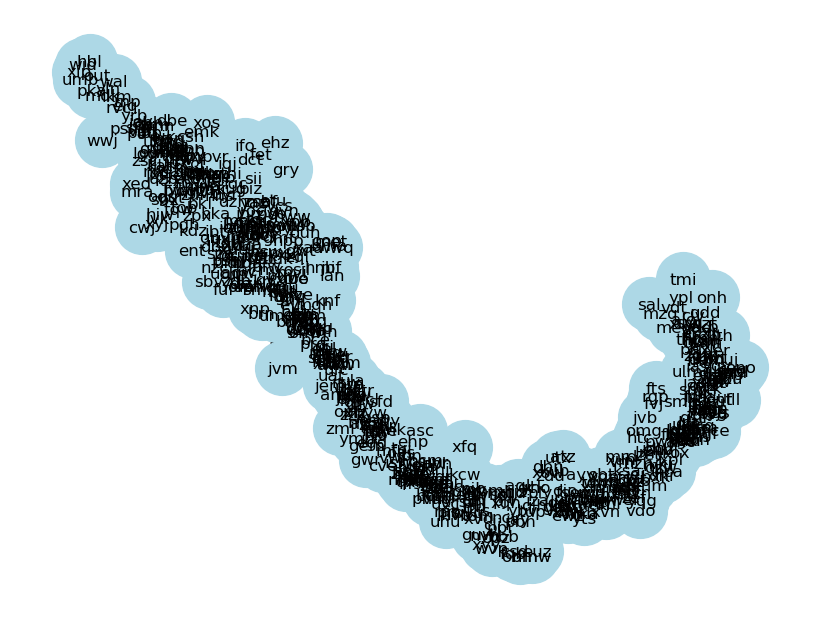

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph(load("11.txt"))

# Draw it
plt.figure(figsize=(8, 6))
nx.draw(G, with_labels=True, node_color='lightblue', 
        node_size=1500, arrowsize=20, font_size=12)
plt.show()


In [3]:


def part2(fn):
    g=load(fn)
    
    def dfs(cur,end,memo):
        if cur==end:
            return 1
        if cur in memo:
            return memo[cur]
        r=0
        if cur in g:
            r=sum(dfs(e,end,memo) for e in g[cur])
        memo[cur]=r
        return r
        
    
    svr_dac=dfs('svr','dac',{})
    print(svr_dac)
    dac_fft=dfs('dac','fft',{})
    print(dac_fft)
    fft_out=dfs('fft','out',{})
    print(fft_out)
    
    svr_fft=dfs('svr','fft',{})
    print(svr_fft)
    fft_dac=dfs('fft','dac',{})
    print(fft_dac)
    dac_out=dfs('dac','out',{})
    print(dac_out)
    
    return svr_dac*dac_fft*fft_out+svr_fft*fft_dac*dac_out


print("part2:", part2("11.txt"), 420257875695750)



                       
                       

1021068541338
0
1322062617256
2073
14611122
13875
part2: 420257875695750 420257875695750
